# Load in BIG_DATA2.csv

In [19]:
import csv
import pandas as pd  
import requests
# TODO FIX URL
url = "https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/BIG_DATA2.csv"
df = pd.read_csv(url, index_col=0)

# Ziyue: Display the Top 5 Genres Over Time

In [1]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

In [2]:
# --- 1. Load Data ---
url = "https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/BIG_DATA2.csv"

print(f"Reading file from URL: {url}")

try:
    df = pd.read_csv(url, index_col=0)
except Exception as e:
    print(f"Error reading the file: {e}")
    sys.exit(1)

Reading file from URL: https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/BIG_DATA2.csv


In [3]:
# --- 2. Identify Top 5 Genres Overall ---
# Calculate the overall top 5 most frequent genres
genre_counts = df['genre'].value_counts()
top_5_genres = genre_counts.head(5).index.tolist()

print("\nOverall Top 5 Genres:")
print(genre_counts.head(5).to_markdown())


Overall Top 5 Genres:
| genre       |   count |
|:------------|--------:|
| Pop         |  106412 |
| Rock        |   47227 |
| R&B         |   40511 |
| Rap/Hip Hop |   35221 |
| Country     |   32739 |


In [5]:
# --- 3. Data Preparation for Time Series ---
# A. Convert 'date' to datetime and extract year

df.reset_index(inplace=True)

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# B. Filter data for the requested years (1958 to 2021)
df_filtered = df[(df['year'] >= 1958) & (df['year'] <= 2021)].copy()

# C. Filter to include only the top 5 genres
df_top5 = df_filtered[df_filtered['genre'].isin(top_5_genres)]

# D. Group by year and genre to get the count of chart appearances
genre_evolution = df_top5.groupby(['year', 'genre']).size().reset_index(name='count')

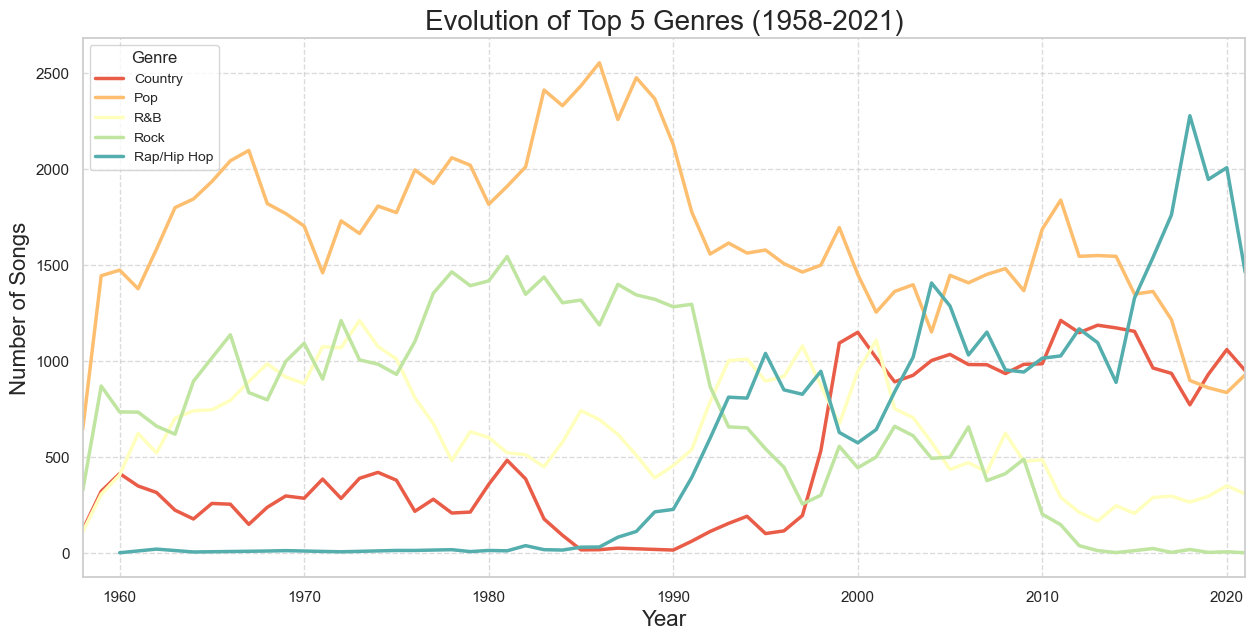

In [6]:
# --- 4. Visualization ---
sns.set_theme(style='whitegrid')

plt.figure(figsize=(15, 7))

# Create the line plot
sns.lineplot(
    data=genre_evolution, 
    x='year', 
    y='count', 
    hue='genre', 
    linewidth=2.5, 
    palette='Spectral',
)

# Set English titles and labels
plt.title('Evolution of Top 5 Genres (1958-2021)', fontsize=20)
plt.xlabel('Year', fontsize=16)
plt.ylabel('Number of Songs', fontsize=16)
plt.legend(title='Genre', title_fontsize='12', fontsize='10', loc='upper left')

# Set explicit X-axis limits and ticks for clarity
plt.xlim(1958, 2021)

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.7)

# Save the chart
output_image_name = 'top_5_genres_visualization.png'
plt.savefig(output_image_name, dpi=300, bbox_inches='tight')
plt.show()

# Namisha: Top 7 Genres Over Time and Missing Genres Over Time

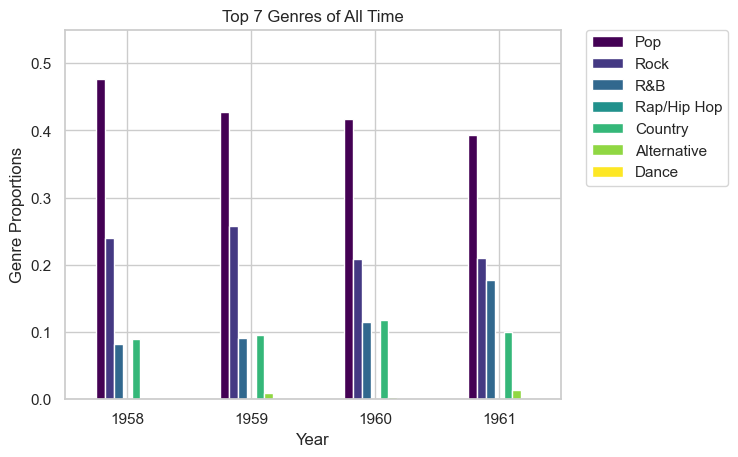

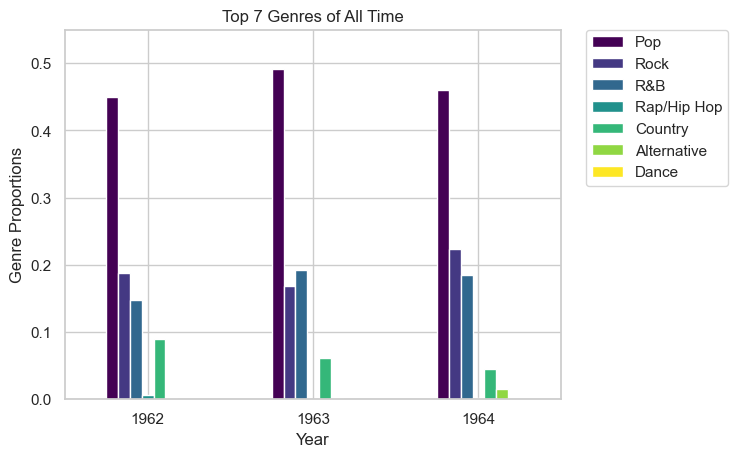

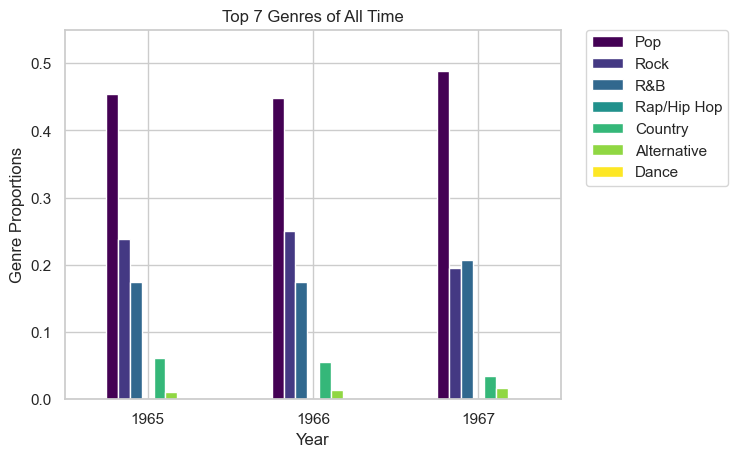

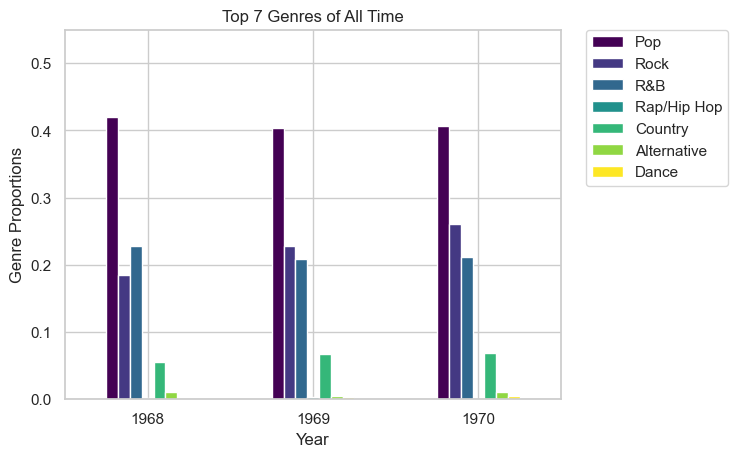

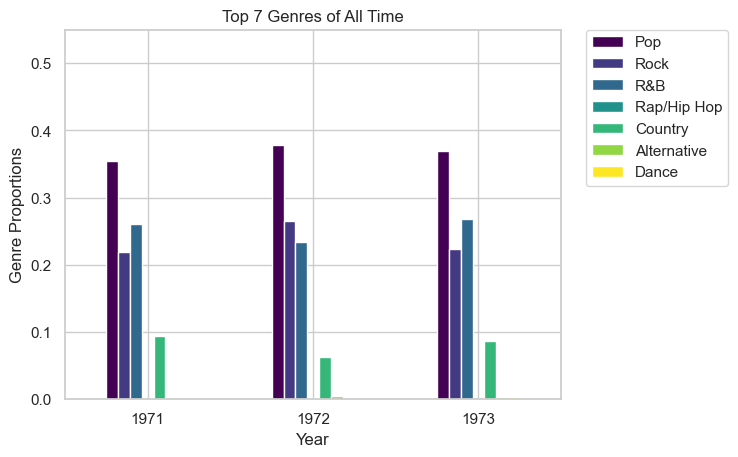

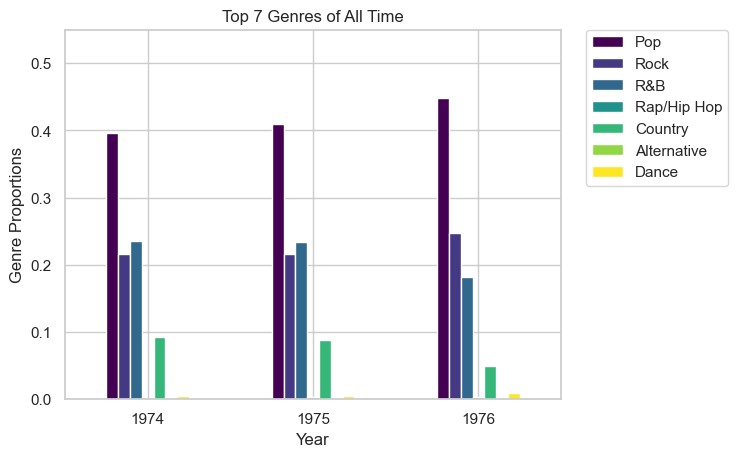

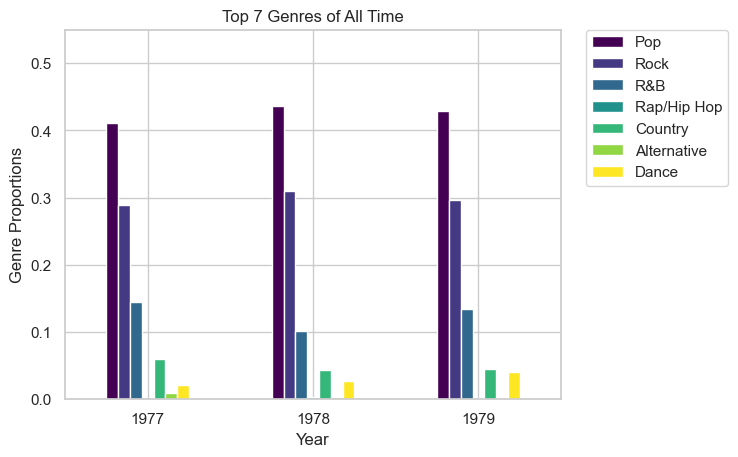

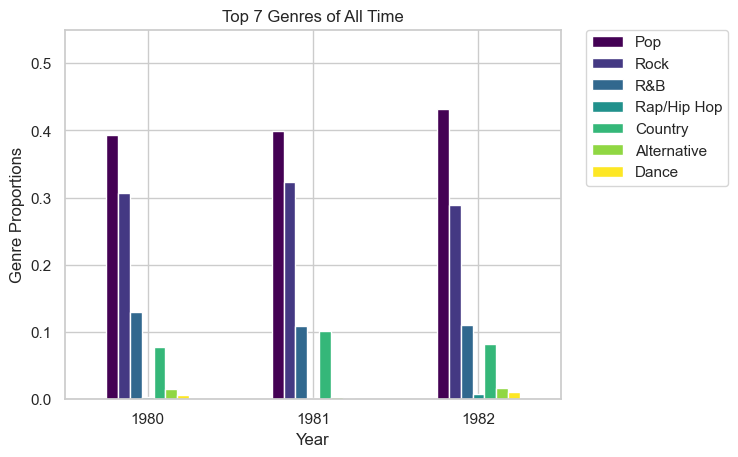

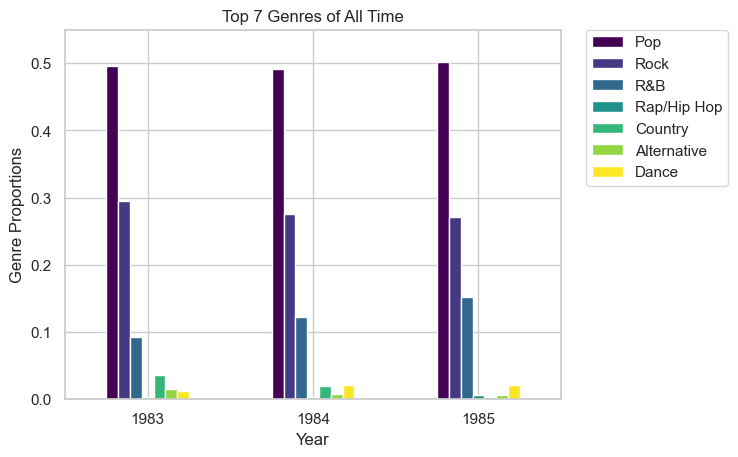

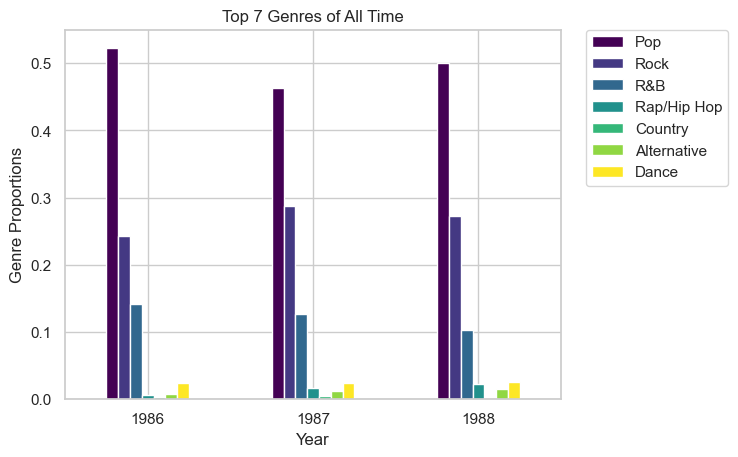

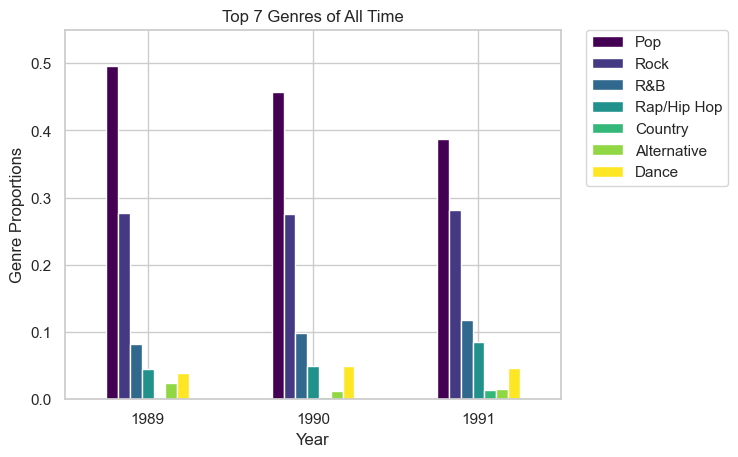

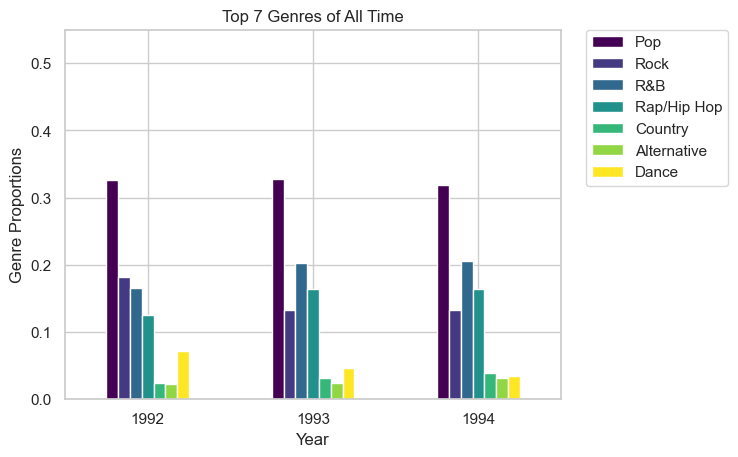

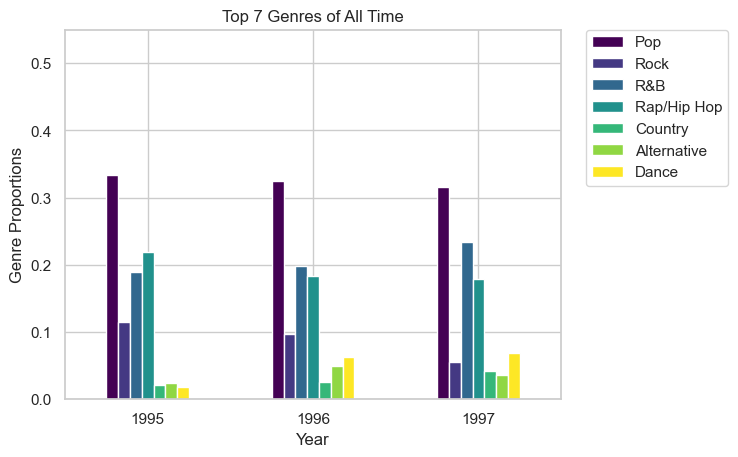

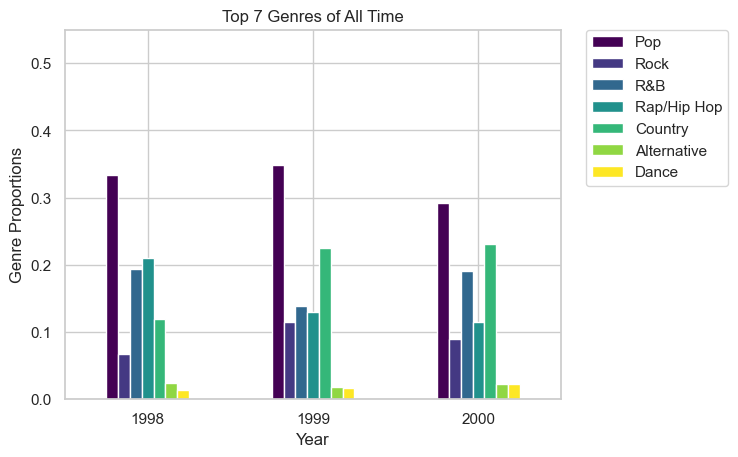

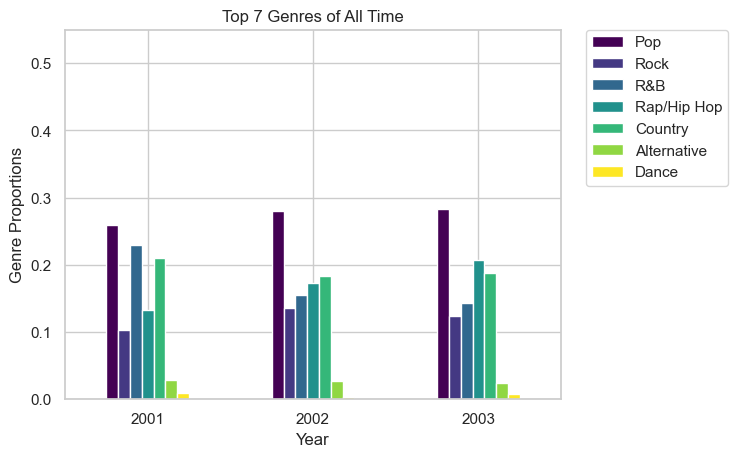

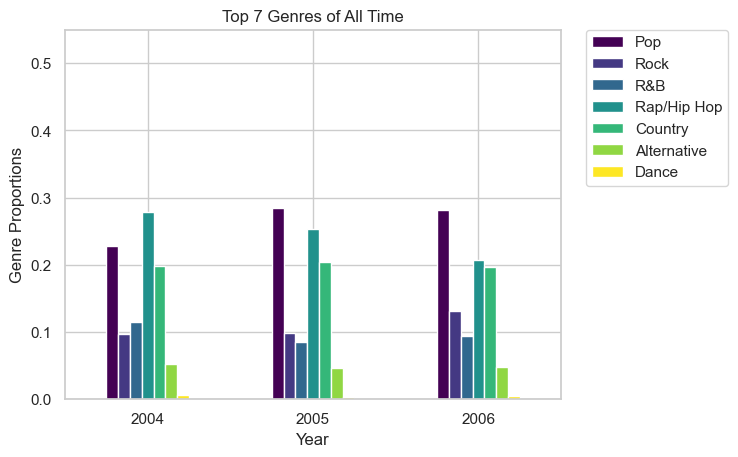

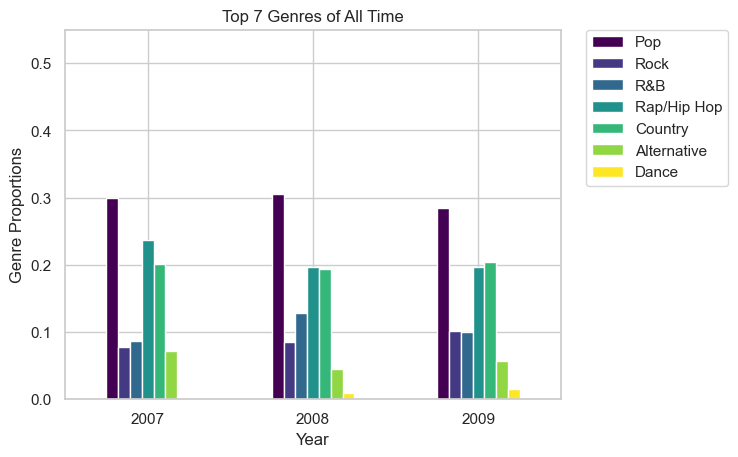

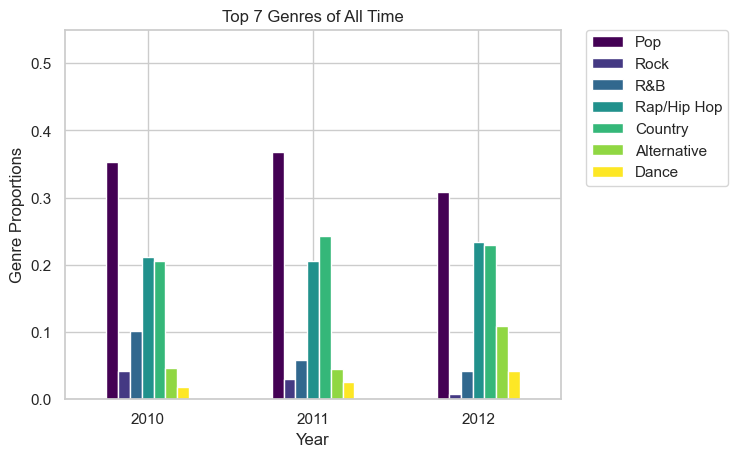

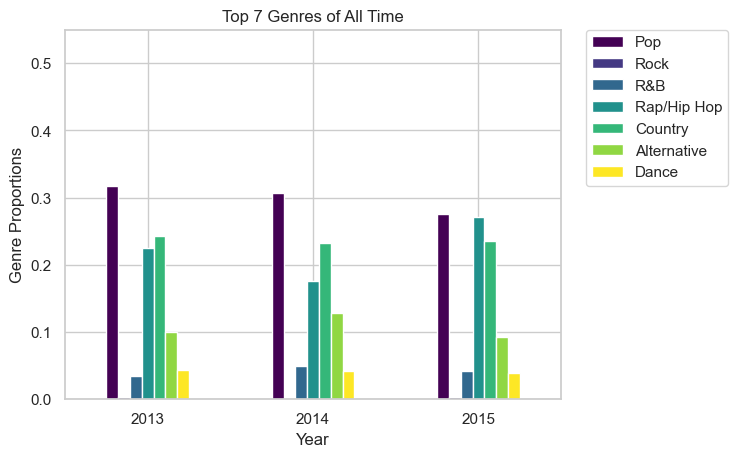

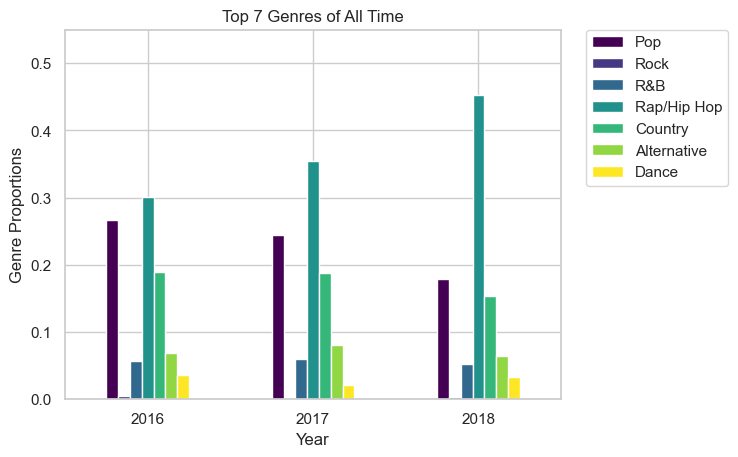

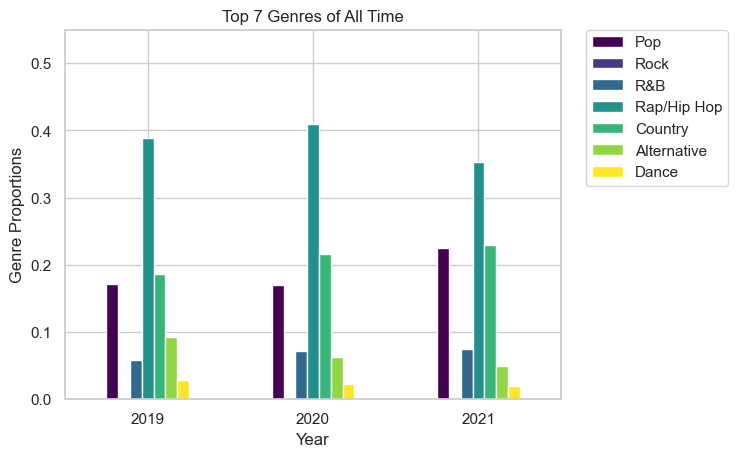

In [7]:
import pandas as pd
import matplotlib.pyplot as plot
import requests


url="https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/BIG_DATA2.csv"
resp=requests.get(url)


# Global Variables 
#INPUT_CSV = "BIG_DATA2.csv" # Input csv must be of format: 
AGG_PERIOD = "Y" # Aggregate period: Choose "Y" for yearly or "W" for weekly

# Asserts
# TODO assert csv columns
#assert(isinstance(INPUT_CSV, str) and ".csv" in INPUT_CSV)
assert(isinstance(AGG_PERIOD,str) and AGG_PERIOD in ["Y","W"])

# 1. Load Dataset: 
# Input columns: date,rank,song,artist,last-week,peak-rank,weeks-on-board,genre
df = pd.read_csv(url)

# print("\nInitial dataframe\n", df) # print initial df

# Parse date as datetime (if not already), coerce data parsing errors
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d',errors='coerce') 
df = df.dropna(subset=['date'])  # Drop rows that can't be parsed/with null values in date

# 2. Clean data:
df = df.dropna(subset=['genre']) # Remove rows missing genres 
# Normalization of genres names if needed here (rnb = r&b = R&B) TODO
#print("\nAfter dropping missing genres:\n",df) 

# 3. Choose aggregation type, yearly or weekly TODO
if(AGG_PERIOD == 'Y'):
    df['period'] = df['date'].dt.to_period('Y').dt.to_timestamp().dt.year # Use Jan 1 YYYY as index
elif(AGG_PERIOD == 'W'):
    # Use ISO Calendar numbering (ex: 2005-01-01	ISO:2004-W53-6) TODO
    iso = df['date'].dt.isocalendar() # returns df week, year, day
    df['period'] = iso['year'].astype(str) + "-W" +iso['week'].astype(str).str.zfill(2)
else:
    raise ValueError("Invalid AGG_PERIOD, must choose 'Y' or 'W'")

# 4. Build new df: proportion table
# Group by period and genre, count how many songs in each period per genre
# essentially asks: how many pop songs were on the chart during this period? how about rap? how aout pop in the next period? etc

genre_counts = df.groupby(['period','genre']).size().reset_index(name='count')
genre_counts['total-in-period'] = genre_counts.groupby('period')['count'].transform('sum')
genre_counts['proportion'] = genre_counts['count'] / genre_counts['total-in-period']
# Now genre_counts looks like form:
# period   genre	count total-in-period proportion
# 2000-W03	pop 	3     100              3/100
# 2010    	r&b 	120   5200            120/5200
proportion_table = genre_counts.pivot(index='period', columns='genre', values='proportion').fillna(0) 
# Make pivot table form:a
# period   pop   rap  ...
# 2000-W03  0.03 0.02
# Remove text after the first space
##############################
# Calculate column sums and sort the column names by these sums in descending order
sorted_columns = proportion_table.sum().sort_values(ascending=False).index

# Reindex the DataFrame with the sorted column names
df_sorted = proportion_table[sorted_columns]
top=7
keep=df_sorted.iloc[:,:top]

########################################
proportion_table.to_csv('props.csv', index=False)
keep.to_csv('props_sortedkeep.csv', index=False)

col_min=0
col_max=0
for col_max in range(4,65,3):
    prop_slice=keep.iloc[col_min:col_max]
    
    prop_slice.plot(kind='bar', colormap='viridis', rot=0)
    plot.title(f'Top {top} Genres of All Time')
    plot.xlabel('Year')
    plot.ylabel('Genre Proportions')
    plot.ylim(0, 0.55)
    plot.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plot.show()
    col_min=col_max

# Rachel: Display the Correlation Analysis

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Load in pre-processed file

In [27]:
import csv
import pandas as pd  
import requests

url = "https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/genre_proportions_by_Y_top_5BIG_DATA2.csv"
df = pd.read_csv(url, index_col=0)

In [28]:
#csv_path = "genre_proportions_by_Y_top_5_BIG_DATA2.csv"
#df = pd.read_csv(csv_path, index_col=0)
corr = df.corr()
corr

,Pop,Rock,R&B,Rap/Hip Hop,Country
Pop,1.000000,0.816063,0.264102,-0.890936,-0.740971
Rock,0.816063,1.000000,0.358507,-0.890715,-0.775491
R&B,0.264102,0.358507,1.000000,-0.508859,-0.467643
Rap/Hip Hop,-0.890936,-0.890715,-0.508859,1.000000,0.679174
Country,-0.740971,-0.775491,-0.467643,0.679174,1.000000


Generate a Clustered Heatmap of genre correlations:

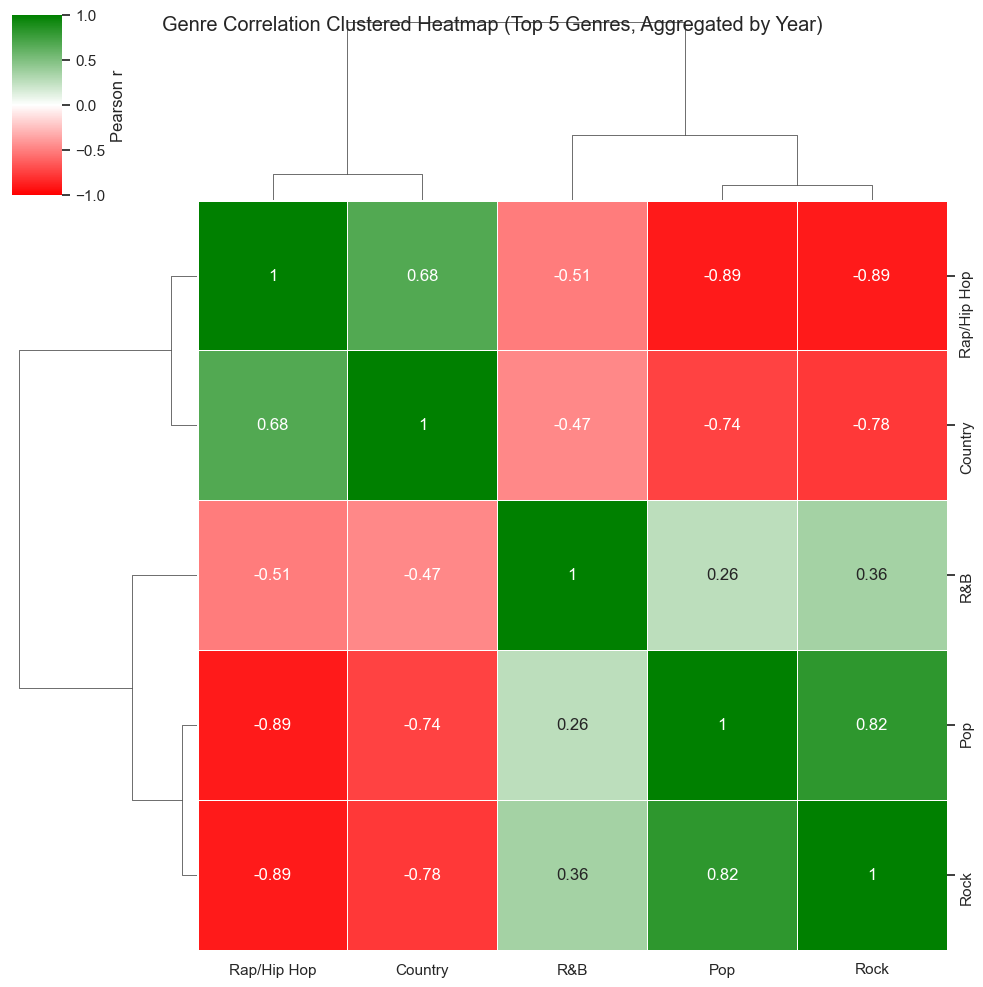

In [29]:
# 7. Visualization: Clustered Heatmap
cmap = mcolors.LinearSegmentedColormap.from_list("custom_corr", ["red","white","green"]) # custom colormap, red -1 white +0 green +1

sns.set_theme(context='notebook', style='white') # Set visual theme as notebook

cluster = sns.clustermap(data=corr, 
                         figsize=(10,10), 
                         metric='euclidean', 
                         method='average',
                         annot=True,
                         cmap=cmap,
                         vmin=-1, vmax=1,center=0, # ensure symmetry
                         cbar_kws={'label': 'Pearson r'},
                         linewidths=0.5
                        )
plt.suptitle('Genre Correlation Clustered Heatmap (Top 5 Genres, Aggregated by Year)')
plt.show()